In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
#| default_exp conv

In [ ]:
from contextlib import contextmanager
from traceback import print_exc

In [ ]:
@contextmanager
def suplog():
  try: yield
  except Exception: print_exc()

## Convolutions

In [ ]:
from pathlib import Path

Path('data/mnist.pkl.gz')

In [ ]:
data = Path('data/mnist.pkl.gz'); data

In [ ]:
import gzip, pickle
from torch import tensor

In [ ]:
with gzip.open(data, 'rb') as f: ((xtrn, ytrn), (xvld, yvld), _) = pickle.load(f, encoding='latin-1')
xtrn, ytrn, xvld, yvld = map(tensor, [xtrn, ytrn, xvld, yvld])

In [ ]:
xtrn[0].shape

torch.Size([784])

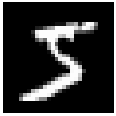

In [ ]:
from xiaoai.core import *

In [ ]:
show_image(xtrn[0].view(-1,28,28));

## Convolutions

A convolution has three pieces: the object, the scanner, and the resulting scan (metaphorically). Respectively, this is the tensor, the kernel, and the activation map.

The amount a kernal shifts across the tensor is known as the stride. A stride of 1 means the kernel moves 1 pixel at a time. A stride of 2 means the kernel moves 2 pixels at a time.

When the kernel is over an area, a dot product is performed between the respective areas of the kernel and tensor.

[Matt Kleinsmith]() shows this the best.

In [ ]:
from matplotlib import rcParams

Type:        RcParams
String form:
_internal.classic_mode: False
           agg.path.chunksize: 0
           animation.bitrate: -1
           animation.codec: h264
           a <...> : True
           ytick.minor.size: 2.0
           ytick.minor.visible: False
           ytick.minor.width: 0.6
           ytick.right: False
Length:      316
File:        ~/miniforge3/envs/default/lib/python3.11/site-packages/matplotlib/__init__.py
Docstring:  
A dict-like key-value store for config parameters, including validation.

Validating functions are defined and associated with rc parameters in
:mod:`matplotlib.rcsetup`.

The list of rcParams is:

- _internal.classic_mode
- agg.path.chunksize
- animation.bitrate
- animation.codec
- animation.convert_args
- animation.convert_path
- animation.embed_limit
- animation.ffmpeg_args
- animation.ffmpeg_path
- animation.frame_format
- animation.html
- animation.writer
- axes.autolimit_mode
- axes.axisbelow
- axes.edgecolor
- axes.facecolor
- axes.formatter

In [ ]:
?rcParams

In [ ]:
rcParams['image.cmap'] = 'gray'
rcParams['figure.dpi'] = 30

In [ ]:
ximgs,xvimgs = xtrn.view(-1,28,28), xvld.view(-1,28,28)

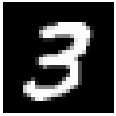

In [ ]:
im3 = ximgs[7]
show_image(im3);

Let's create a kernel that detects the top edge of digits.

In [ ]:
top_edge = tensor([[-1,-1,-1],
                   [ 0, 0, 0],
                   [ 1, 1, 1]]).float()

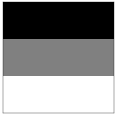

In [ ]:
show_image(top_edge, noframe=False);

Let's visualize how our kernel detects top edges.

In [ ]:
import pandas as pd


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
5,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.15,0.17,0.41,1.00,0.99,0.99,0.99,0.99,0.99,0.68,0.02,0.00
6,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.17,0.54,0.88,0.88,0.98,0.99,0.98,0.98,0.98,0.98,0.98,0.98,0.62,0.05
7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.70,0.98,0.98,0.98,0.98,0.99,0.98,0.98,0.98,0.98,0.98,0.98,0.98,0.23
8,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.43,0.98,0.98,0.90,0.52,0.52,0.52,0.52,0.74,0.98,0.98,0.98,0.98,0.23
9,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.11,0.11,0.09,0.00,0.00,0.00,0.00,0.05,0.88,0.98,0.98,0.67,0.03


In [ ]:
df = pd.DataFrame(im3[:13,:23])
df.style.format(precision=2).set_properties(**{'font-size':'7pt'}).background_gradient('Greys')

Let's apply the kernel to the utmost top edge.

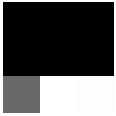

In [ ]:
show_image(im3[3:6,13:16]);

In [ ]:
top_edge.shape, im3[3:6,13:16].shape

(torch.Size([3, 3]), torch.Size([3, 3]))

In [ ]:
(top_edge*im3[3:6,13:16]).sum()

tensor(2.3945)

Now let's try the bottom most edge of the very same portion of the digit.

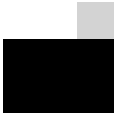

In [ ]:
show_image(im3[9:12,10:13]);

In [ ]:
(top_edge*im3[9:12,10:13]).sum()

tensor(-0.3203)

We managed to use our `top_edge` kernel to detect the bottom edge of the digit. A larger number means the edge is more likely a top edge. A smaller number means it is more likely a bottom edge.

In [ ]:
def apply_kernel(row, col, kernel): return (kernel*im3[row-1:row+2,col-1:col+2]).sum()

In [ ]:
apply_kernel(10,11,top_edge)

tensor(-0.3203)

Let's apply the kernel across the whole image to detect all top edges (and bottom edges).

In [ ]:
for r in range(im3.shape[0]): print(r)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27


In [ ]:
import torch

torch.Size([28, 28])

In [ ]:
detect = torch.zeros_like(im3); detect.shape

As our kernel has a stride of 1, and we are not applying any other fancy processing techniques, we will loose 1 pixel region around the tensor. This will result in a 27x27 pixel activation map.

(torch.Size([26, 26]), <Axes: >)

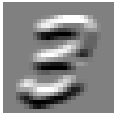

In [ ]:
rng = range(1,27)
top_edge3 = tensor([[apply_kernel(r,c,top_edge) for c in rng] for r in rng])
top_edge3.shape, show_image(top_edge3)

Let's detect left edges.

(tensor([[-1., -1., -1.],
         [ 0.,  0.,  0.],
         [ 1.,  1.,  1.]]),
 <Axes: >)

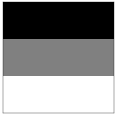

In [ ]:
top_edge, show_image(top_edge, noframe=False)

In [ ]:
left_edge = tensor([[-1,0,1],
                   [-1,0,1],
                   [-1,0,1]]).float()

<Axes: >

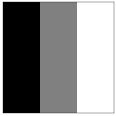

In [ ]:
show_image(left_edge, noframe=False)

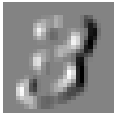

In [ ]:
left_edge3 = tensor([[apply_kernel(r,c,left_edge) for c in rng] for r in rng])
show_image(left_edge3);

### Convolutions in PyTorch

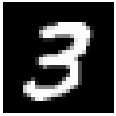

In [ ]:
show_image(im3);

In [ ]:
im3.shape

torch.Size([28, 28])

Let's assume a 2x2 kernel. This would mean that the pixels at positions (0,0), (0,1), (1,0), and (1,1) will need to be rerranged to form one row of the new matrix.

In [ ]:
im3[0,0], im3[0,1], im3[1,0], im3[1,1]

(tensor(0.), tensor(0.), tensor(0.), tensor(0.))

With stride 1, the next pixels to be rearranged would be at positions (0,1), (0,2), (1,1), and (1,2).

In [ ]:
im3[0,1], im3[0,2], im3[1,1], im3[1,2]

(tensor(0.), tensor(0.), tensor(0.), tensor(0.))

The next pixels are at (0,2), (0,3), (1,2), and (1,3).

In [ ]:
im3[0,2], im3[0,3], im3[1,2], im3[1,3]

(tensor(0.), tensor(0.), tensor(0.), tensor(0.))

Once the end of the zeroth row is reached, and we shift to the next row, the new pixels would be at positions (1,0), (1,1), (2,0), and (2,1).

In [ ]:
im3[1,0], im3[1,1], im3[2,0], im3[2,1]

(tensor(0.), tensor(0.), tensor(0.), tensor(0.))

Then the next group of pixels are (1,1), (1,2), (2,1), and (2,2).

In [ ]:
im3[1,1], im3[1,2], im3[2,1], im3[2,2]

(tensor(0.), tensor(0.), tensor(0.), tensor(0.))

Let's create a preliminary reshaping loop.

In [ ]:
matrix = []
for r in range(im3.shape[0]-1):
  for c in range(im3.shape[1]-1):
    matrix.append(tensor([im3[r,c], im3[r,c+1], im3[r+1,c], im3[r+1,c+1]]))

In [ ]:
len(matrix)

729

In [ ]:
matrix = torch.stack(matrix); matrix.shape, matrix

(torch.Size([729, 4]),
 tensor([[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.],
         ...,
         [0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]))

In [ ]:
show_image(matrix);

In [ ]:
def im2col(im:torch.Tensor):
  matrix = []
  for r in range(im.shape[0]-1):
    for c in range(im3.shape[1]-1):
      matrix.append(tensor([im[r  ,c], im[r  ,c+1],
                            im[r+1,c], im[r+1,c+1]
                            ]))
  return torch.stack(matrix)

Let's confirm out function matches our prior matrix.

In [ ]:
from fastcore.all import *

In [ ]:
test_eq(matrix, im2col(im3))

For a 3x3 kernel, we simply need to branch out 2 places from the kernel's anchor point.

In [ ]:
matrix = []
for r in range(im3.shape[0]-3):
  for c in range(im3.shape[1]-3):
    matrix.append(tensor([im3[r  ,c], im3[r  ,c+1], im3[r  ,c+2],
                          im3[r+1,c], im3[r+1,c+1], im3[r+1,c+2],
                          im3[r+2,c], im3[r+2,c+1], im3[r+2,c+2]
                          ]))

In [ ]:
matrix = torch.stack(matrix); matrix.shape

torch.Size([625, 9])

In [ ]:
show_image(matrix);

In a 2x2 kernel, we only branch out 1 place. In a 3x3 kernel, we branch out 3.

In [ ]:
im3[0:2,0:2], im3[0:3,0:3]

(tensor([[0., 0.],
         [0., 0.]]),
 tensor([[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]))

Manually specifying all items of the tensor will not be feasible. Therefore, I need to figure out a slicing operation that will handle it for us.

In [ ]:
im3[0:0+3,0:0+3]

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

In [ ]:
t = tensor([[1,2,3,4],
            [5,6,7,8],
            [9,10,11,12],
            [13,14,15,16]]); t

tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12],
        [13, 14, 15, 16]])

In [ ]:
t[0:0+3,0:0+3], t[0:0+3,0:0+3].flatten()

(tensor([[ 1,  2,  3],
         [ 5,  6,  7],
         [ 9, 10, 11]]),
 tensor([ 1,  2,  3,  5,  6,  7,  9, 10, 11]))

In [ ]:
m2 = []
for r in range(im3.shape[0]-3):
  for c in range(im3.shape[1]-3):
    m2.append(im3[r:r+3, c:c+3].flatten())

In [ ]:
m2 = torch.stack(m2); m2.shape

torch.Size([625, 9])

In [ ]:
test_eq(m2, matrix)

My slicing operation implementation matches my prior implementation. Let's encapsulate.

In [ ]:
def im2col(im:torch.Tensor, kw:int, kh:int):
  matrix = []
  for r in range(im.shape[0]-kw):
    for c in range(im.shape[0]-kh):
      matrix.append(tensor(im[r:r+kw, c:c+kh]).flatten())
  return torch.stack(matrix)

In [ ]:
test_eq(im2col(im3,3,3), matrix)

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/2292503785.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matrix.append(tensor(im[r:r+kw, c:c+kh]).flatten())


Right now, I'm assuming my `im2col` implementation is correct. I'm going to verify whether it actually is by comparing it against PyTorch's `F.unfold`.

In [ ]:
import torch.nn.functional as F

Signature:
F.unfold(
    input: torch.Tensor,
    kernel_size: None,
    dilation: None = 1,
    padding: None = 0,
    stride: None = 1,
) -> torch.Tensor
Docstring:
Extract sliding local blocks from a batched input tensor.

.. warning::
    Currently, only 4-D input tensors (batched image-like tensors) are
    supported.

.. warning::

    More than one element of the unfolded tensor may refer to a single
    memory location. As a result, in-place operations (especially ones that
    are vectorized) may result in incorrect behavior. If you need to write
    to the tensor, please clone it first.


See :class:`torch.nn.Unfold` for details
File:      ~/miniforge3/envs/default/lib/python3.11/site-packages/torch/nn/functional.py
Type:      function

In [ ]:
?F.unfold

`F.unfold` only works on 4D tensors

In [ ]:
im3[None,None,...].shape

torch.Size([1, 1, 28, 28])

In [ ]:
F.unfold(im3[None,None,...],(3,3)).shape

torch.Size([1, 9, 676])

Technically, my `im2col` function is `im2row`. So I'll have to permute the resulting tensor so the dimensions match.

In [ ]:
im2col(im3,3,3).shape, im2col(im3,3,3).permute(1,0).shape

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/2292503785.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matrix.append(tensor(im[r:r+kw, c:c+kh]).flatten())


(torch.Size([625, 9]), torch.Size([9, 625]))

Aaand we can already see that my implementation is incorrect.

In [ ]:
with suplog(): test_eq(im2col(im3,3,3).permute(1,0), F.unfold(im3[None,None,...],(3,3))[0,...])

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/2292503785.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matrix.append(tensor(im[r:r+kw, c:c+kh]).flatten())
Traceback (most recent call last):
  File "/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/3865905382.py", line 5, in suplog
    try: yield
         ^^^^^
  File "/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/723384084.py", line 1, in <module>
    with suplog(): test_eq(im2col(im3,3,3).permute(1,0), F.unfold(im3[None,None,...],(3,3))[0,...])
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/salmannaqvi/miniforge3/envs/default/lib/python3.11/site-packages/fastcore/test.py", line 39, in test_eq
    test(a,b,equals, cname='==')
  File "/Users/salmannaqvi/miniforge3/e

PyTorch's base implementation reduces our 28x28 image to a 26x26 image. My implementation loses an additional border of pixels, resulting in a 25x25 image.

In [ ]:
26*26, 25*25

(676, 625)

I'm going to see if the issue pertains to the range of the for loops.

In [ ]:
def im2col(im:torch.Tensor, kw:int, kh:int):
  matrix = []
  for r in range(im.shape[0]-kw+1):
    for c in range(im.shape[0]-kh+1):
      matrix.append(tensor(im[r:r+kw, c:c+kh]).flatten())
  return torch.stack(matrix)

In [ ]:
im2col(tensor([[1,2,3,4],[5,6,7,8],[9,10,11,12],[13,14,15,16]]), 3,3)

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/4074321543.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matrix.append(tensor(im[r:r+kw, c:c+kh]).flatten())


tensor([[ 1,  2,  3,  5,  6,  7,  9, 10, 11],
        [ 2,  3,  4,  6,  7,  8, 10, 11, 12],
        [ 5,  6,  7,  9, 10, 11, 13, 14, 15],
        [ 6,  7,  8, 10, 11, 12, 14, 15, 16]])

In [ ]:
test_eq(im2col(im3,3,3).permute(1,0), F.unfold(im3[None,None,...],(3,3))[0,...])

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/4074321543.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matrix.append(tensor(im[r:r+kw, c:c+kh]).flatten())


It was indeed! I'll now test whether nonsquare kernels correctly work.

In [ ]:
test_eq(im2col(im3,2,3).permute(1,0), F.unfold(im3[None,None,...],(2,3))[0,...])

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/4074321543.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matrix.append(tensor(im[r:r+kw, c:c+kh]).flatten())


They do! I'll now add padding functionality.

In [ ]:
t

tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12],
        [13, 14, 15, 16]])

In [ ]:
?torch.zeros

Docstring:
zeros(*size, *, out=None, dtype=None, layout=torch.strided, device=None, requires_grad=False) -> Tensor

Returns a tensor filled with the scalar value `0`, with the shape defined
by the variable argument :attr:`size`.

Args:
    size (int...): a sequence of integers defining the shape of the output tensor.
        Can be a variable number of arguments or a collection like a list or tuple.

Keyword args:
    out (Tensor, optional): the output tensor.
    dtype (:class:`torch.dtype`, optional): the desired data type of returned tensor.
        Default: if ``None``, uses a global default (see :func:`torch.set_default_dtype`).
    layout (:class:`torch.layout`, optional): the desired layout of returned Tensor.
        Default: ``torch.strided``.
    device (:class:`torch.device`, optional): the desired device of returned tensor.
        Default: if ``None``, uses the current device for the default tensor type
        (see :func:`torch.set_default_device`). :attr:`device` will be

In [ ]:
torch.zeros(1, t.shape[1])

tensor([[0., 0., 0., 0.]])

In [ ]:
t_ = torch.concat([t, torch.zeros(1,t.shape[1], dtype=int)]); t_

tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12],
        [13, 14, 15, 16],
        [ 0,  0,  0,  0]])

In [ ]:
t_ = torch.concat([torch.zeros(1,t.shape[1], dtype=int),t_]); t_

tensor([[ 0,  0,  0,  0],
        [ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12],
        [13, 14, 15, 16],
        [ 0,  0,  0,  0]])

In [ ]:
?torch.concat

Docstring:
concat(tensors, dim=0, *, out=None) -> Tensor

Alias of :func:`torch.cat`.
Type:      builtin_function_or_method

In [ ]:
t_.shape

torch.Size([6, 4])

In [ ]:
torch.zeros(t_.shape[0],dtype=int)

tensor([0, 0, 0, 0, 0, 0])

In [ ]:
t_ = torch.concat([torch.zeros(t_.shape[0],1,dtype=int),t_],dim=1); t_

tensor([[ 0,  0,  0,  0,  0],
        [ 0,  1,  2,  3,  4],
        [ 0,  5,  6,  7,  8],
        [ 0,  9, 10, 11, 12],
        [ 0, 13, 14, 15, 16],
        [ 0,  0,  0,  0,  0]])

In [ ]:
t_ = torch.concat([t_,torch.zeros(t_.shape[0],1,dtype=int)],dim=1); t_

tensor([[ 0,  0,  0,  0,  0,  0],
        [ 0,  1,  2,  3,  4,  0],
        [ 0,  5,  6,  7,  8,  0],
        [ 0,  9, 10, 11, 12,  0],
        [ 0, 13, 14, 15, 16,  0],
        [ 0,  0,  0,  0,  0,  0]])

In [ ]:
?F.pad

Signature:
F.pad(
    input: torch.Tensor,
    pad: List[int],
    mode: str = 'constant',
    value: Optional[float] = None,
) -> torch.Tensor
Docstring:
pad(input, pad, mode="constant", value=None) -> Tensor

Pads tensor.

Padding size:
    The padding size by which to pad some dimensions of :attr:`input`
    are described starting from the last dimension and moving forward.
    :math:`\left\lfloor\frac{\text{len(pad)}}{2}\right\rfloor` dimensions
    of ``input`` will be padded.
    For example, to pad only the last dimension of the input tensor, then
    :attr:`pad` has the form
    :math:`(\text{padding\_left}, \text{padding\_right})`;
    to pad the last 2 dimensions of the input tensor, then use
    :math:`(\text{padding\_left}, \text{padding\_right},`
    :math:`\text{padding\_top}, \text{padding\_bottom})`;
    to pad the last 3 dimensions, use
    :math:`(\text{padding\_left}, \text{padding\_right},`
    :math:`\text{padding\_top}, \text{padding\_bottom}`
    :math:`\text{pad

In [ ]:
F.pad(t,(1,1))

tensor([[ 0,  1,  2,  3,  4,  0],
        [ 0,  5,  6,  7,  8,  0],
        [ 0,  9, 10, 11, 12,  0],
        [ 0, 13, 14, 15, 16,  0]])

In [ ]:
F.pad(t,(1,1,1,1))

tensor([[ 0,  0,  0,  0,  0,  0],
        [ 0,  1,  2,  3,  4,  0],
        [ 0,  5,  6,  7,  8,  0],
        [ 0,  9, 10, 11, 12,  0],
        [ 0, 13, 14, 15, 16,  0],
        [ 0,  0,  0,  0,  0,  0]])

In [ ]:
??F.pad

Signature:
F.pad(
    input: torch.Tensor,
    pad: List[int],
    mode: str = 'constant',
    value: Optional[float] = None,
) -> torch.Tensor
Source:   
def pad(input: Tensor, pad: List[int], mode: str = "constant", value: Optional[float] = None) -> Tensor:
    r"""
pad(input, pad, mode="constant", value=None) -> Tensor

Pads tensor.

Padding size:
    The padding size by which to pad some dimensions of :attr:`input`
    are described starting from the last dimension and moving forward.
    :math:`\left\lfloor\frac{\text{len(pad)}}{2}\right\rfloor` dimensions
    of ``input`` will be padded.
    For example, to pad only the last dimension of the input tensor, then
    :attr:`pad` has the form
    :math:`(\text{padding\_left}, \text{padding\_right})`;
    to pad the last 2 dimensions of the input tensor, then use
    :math:`(\text{padding\_left}, \text{padding\_right},`
    :math:`\text{padding\_top}, \text{padding\_bottom})`;
    to pad the last 3 dimensions, use
    :math:`(\text{pa

I have a hunch my concatenation approach to padding is quite slow. I'm going to time it.

In [ ]:
%%timeit
t_ = torch.concat((t, torch.zeros(1,t.shape[1], dtype=int)))
t_ = torch.concat((torch.zeros(1,t.shape[1], dtype=int),t_))
t_ = torch.concat((torch.zeros(t_.shape[0],1,dtype=int),t_),dim=1)
t_ = torch.concat((t_,torch.zeros(t_.shape[0],1,dtype=int)),dim=1)

21.2 μs ± 284 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In a vacuum, 21.4μs seems pretty quick! but now let's time `F.pad` and see how that runs.

In [ ]:
%timeit F.pad(t,(1,1,1,1))

5.06 μs ± 14.8 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


_Much_ quicker! Roughly a 4x speed up!

An alternative approach I can try is to create a tensor of zeros that is the size of our input tensor plus the padding amount.

In [ ]:
t_ = torch.zeros(t.shape); t_.shape

torch.Size([4, 4])

In [ ]:
t_ = torch.zeros(t.shape[0]+2,t.shape[1]+2, dtype=int); t_, t_.shape

(tensor([[0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0]]),
 torch.Size([6, 6]))

In [ ]:
t[0,:]

tensor([1, 2, 3, 4])

In [ ]:
t_[1,1:-2]

tensor([0, 0, 0])

In [ ]:
t, t[1,1:-2], t[1,1:-1]

(tensor([[ 1,  2,  3,  4],
         [ 5,  6,  7,  8],
         [ 9, 10, 11, 12],
         [13, 14, 15, 16]]),
 tensor([6]),
 tensor([6, 7]))

In [ ]:
t_[1,1:-1] = t[0,:]; t_

tensor([[0, 0, 0, 0, 0, 0],
        [0, 1, 2, 3, 4, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0]])

In [ ]:
t[1:3,1:-1]

tensor([[ 6,  7],
        [10, 11]])

In [ ]:
t_[1:t.shape[0]+1,1:-1] = t; t_

tensor([[ 0,  0,  0,  0,  0,  0],
        [ 0,  1,  2,  3,  4,  0],
        [ 0,  5,  6,  7,  8,  0],
        [ 0,  9, 10, 11, 12,  0],
        [ 0, 13, 14, 15, 16,  0],
        [ 0,  0,  0,  0,  0,  0]])

In [ ]:
%%timeit
t_ = torch.zeros(t.shape[0]+2,t.shape[1]+2, dtype=int)
t_[1:t.shape[0]+1,1:-1] = t

5.84 μs ± 298 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


And now I roughly match PyTorch's speed. I'll now add this padding logic to my function.

I plan to either let padding be automatically calculated, if the kernel is square of a negative size, or for the padding to be manually specified.

For autocalculation, the general rule of thumb is to floor divide the kernel size by 2. This keeps the resulting activation map the same size as the input tensor, given the kernel is an odd square.



In [ ]:
bool(0), bool(1)

(False, True)

In [ ]:
padding = 5//2; padding

2

In [ ]:
t.shape

torch.Size([4, 4])

In [ ]:
t_ = torch.zeros(t.shape[0]+padding*2,t.shape[1]+padding*2,dtype=int); t_

tensor([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0]])

In [ ]:
padding = 7//2
t_ = torch.zeros(t.shape[0]+padding*2,t.shape[1]+padding*2,dtype=int); t_

tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [ ]:
t_[padding:-padding,padding:-padding] = t; t_

tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  1,  2,  3,  4,  0,  0,  0],
        [ 0,  0,  0,  5,  6,  7,  8,  0,  0,  0],
        [ 0,  0,  0,  9, 10, 11, 12,  0,  0,  0],
        [ 0,  0,  0, 13, 14, 15, 16,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0]])

In [ ]:
def im2col(im:torch.Tensor, kw:int, kh:int, pad:bool|int=0):
  im_ = im
  if pad:
    if (kw==kh) and (kw%2==1) : pad=kw//2
    im_ = torch.zeros(im.shape[0]+pad*2, im.shape[1]+pad*2, dtype=int)
    im_[pad:-pad,pad:-pad] = im

  matrix = []
  for r in range(im_.shape[0]-kw+1):
    for c in range(im_.shape[0]-kh+1):
      matrix.append(tensor(im_[r:r+kw, c:c+kh]).flatten())
  return torch.stack(matrix)

In [ ]:
show_image(im2col(im3, 3,3)), show_image(im2col(im3,3,3,True));

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/682097488.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matrix.append(tensor(im_[r:r+kw, c:c+kh]).flatten())


In [ ]:
im2col(im3,3,3).shape, im2col(im3,3,3,True).shape

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/682097488.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matrix.append(tensor(im_[r:r+kw, c:c+kh]).flatten())


(torch.Size([676, 9]), torch.Size([784, 9]))

As you can see, since I have used a 3x3 kernel, we have retained the original image size when padding.

In [ ]:
im2col(im3,3,3,True)

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/682097488.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matrix.append(tensor(im_[r:r+kw, c:c+kh]).flatten())


tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])

In [ ]:
?F.unfold

Signature:
F.unfold(
    input: torch.Tensor,
    kernel_size: None,
    dilation: None = 1,
    padding: None = 0,
    stride: None = 1,
) -> torch.Tensor
Docstring:
Extract sliding local blocks from a batched input tensor.

.. warning::
    Currently, only 4-D input tensors (batched image-like tensors) are
    supported.

.. warning::

    More than one element of the unfolded tensor may refer to a single
    memory location. As a result, in-place operations (especially ones that
    are vectorized) may result in incorrect behavior. If you need to write
    to the tensor, please clone it first.


See :class:`torch.nn.Unfold` for details
File:      ~/miniforge3/envs/default/lib/python3.11/site-packages/torch/nn/functional.py
Type:      function

In [ ]:
test_eq(im2col(im3,3,3).permute(1,0), F.unfold(im3[None,None,...],(3,3))[0,...])

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/682097488.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matrix.append(tensor(im_[r:r+kw, c:c+kh]).flatten())


In [ ]:
with suplog(): test_eq(im2col(im3,3,3,1).permute(1,0), F.unfold(im3[None,None,...],(3,3),padding=(1,1))[0,...])

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/682097488.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matrix.append(tensor(im_[r:r+kw, c:c+kh]).flatten())
Traceback (most recent call last):
  File "/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/3865905382.py", line 5, in suplog
    try: yield
         ^^^^^
  File "/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/1699385579.py", line 1, in <module>
    with suplog(): test_eq(im2col(im3,3,3,1).permute(1,0), F.unfold(im3[None,None,...],(3,3),padding=(1,1))[0,...])
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/salmannaqvi/miniforge3/envs/default/lib/python3.11/site-packages/fastcore/test.py", line 39, in test_eq
    test(a,b,equals, cname='==')
  Fil

It seems that the test failed because of different data types. I'll fix that.

In [ ]:
def im2col(im:torch.Tensor, kw:int, kh:int, pad:bool|int=0):
  im_ = im
  if pad:
    if (kw==kh) and (kw%2==1): pad=kw//2
    im_ = torch.zeros(im.shape[0]+pad*2, im.shape[1]+pad*2)
    im_[pad:-pad,pad:-pad] = im

  matrix = []
  for r in range(im_.shape[0]-kw+1):
    for c in range(im_.shape[0]-kh+1):
      matrix.append(tensor(im_[r:r+kw, c:c+kh]).flatten())
  return torch.stack(matrix)

In [ ]:
test_eq(im2col(im3,3,3,1).permute(1,0), F.unfold(im3[None,None,...],(3,3),padding=(1,1))[0,...])

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/2054629304.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matrix.append(tensor(im_[r:r+kw, c:c+kh]).flatten())


And now it passes!

Time for stride.

In [ ]:
t

tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12],
        [13, 14, 15, 16]])

In [ ]:
matrix = []
for r in range(t.shape[0]-2+1):
  for c in range(t.shape[0]-2+1):
    print(tensor(t[r:r+2, c:c+2]).flatten())

tensor([1, 2, 5, 6])
tensor([2, 3, 6, 7])
tensor([3, 4, 7, 8])
tensor([ 5,  6,  9, 10])
tensor([ 6,  7, 10, 11])
tensor([ 7,  8, 11, 12])
tensor([ 9, 10, 13, 14])
tensor([10, 11, 14, 15])
tensor([11, 12, 15, 16])


/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/2339776352.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  print(tensor(t[r:r+2, c:c+2]).flatten())


In [ ]:
matrix = []
for r in range(0, t.shape[0]-2+1, 2):
  for c in range(0, t.shape[0]-2+1, 2):
    print(tensor(t[r:r+2, c:c+2]).flatten())

tensor([1, 2, 5, 6])
tensor([3, 4, 7, 8])
tensor([ 9, 10, 13, 14])
tensor([11, 12, 15, 16])


/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/3940382730.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  print(tensor(t[r:r+2, c:c+2]).flatten())


Implementing stride will be as simple as setting the step parameter in the for loops.

In [ ]:
def im2col(im:torch.Tensor, kw:int, kh:int, pad:bool|int=0, stride=1):
  im_ = im
  if pad:
    if kw==kh and (kw%2==1): pad=kw//2
    im_ = torch.zeros(im.shape[0]+pad*2, im.shape[1]+pad*2)
    im_[pad:-pad,pad:-pad] = im

  matrix = []
  for r in range(0,im_.shape[0]-kw+1,stride):
    for c in range(0,im_.shape[0]-kh+1,stride):
      matrix.append(tensor(im_[r:r+kw, c:c+kh]).flatten())
  return torch.stack(matrix)

In [ ]:
test_eq(im2col(im3,3,3).permute(1,0), F.unfold(im3[None,None,...],(3,3))[0,...])

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/2680794255.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matrix.append(tensor(im_[r:r+kw, c:c+kh]).flatten())


In [ ]:
test_eq(im2col(im3,3,3,1).permute(1,0), F.unfold(im3[None,None,...],(3,3),padding=(1,1))[0,...])

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/2680794255.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matrix.append(tensor(im_[r:r+kw, c:c+kh]).flatten())


In [ ]:
test_eq(im2col(im3,3,3,stride=2).permute(1,0), F.unfold(im3[None,None,...],(3,3),stride=2)[0,...])

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/2680794255.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matrix.append(tensor(im_[r:r+kw, c:c+kh]).flatten())


In [ ]:
with suplog(): test_eq(im2col(im3,3,3,pad=2,stride=2).permute(1,0), F.unfold(im3[None,None,...],(3,3),padding=(2,2),stride=2)[0,...])

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/2680794255.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matrix.append(tensor(im_[r:r+kw, c:c+kh]).flatten())
Traceback (most recent call last):
  File "/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/3865905382.py", line 5, in suplog
    try: yield
         ^^^^^
  File "/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/228466670.py", line 1, in <module>
    with suplog(): test_eq(im2col(im3,3,3,pad=2,stride=2).permute(1,0), F.unfold(im3[None,None,...],(3,3),padding=(2,2),stride=2)[0,...])
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/salmannaqvi/miniforge3/envs/default/lib/python3.11/site-packages/fastcore/test.py", line 39, in te

🙄

Error again! With padding _and_ stride, I'm obtaining an incorrect resulting shape.

In [ ]:
with suplog(): test_eq(im2col(im3,3,3,pad=2).permute(1,0), F.unfold(im3[None,None,...],(3,3),padding=(2,2))[0,...])

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/2680794255.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matrix.append(tensor(im_[r:r+kw, c:c+kh]).flatten())
Traceback (most recent call last):
  File "/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/3865905382.py", line 5, in suplog
    try: yield
         ^^^^^
  File "/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/2540323105.py", line 1, in <module>
    with suplog(): test_eq(im2col(im3,3,3,pad=2).permute(1,0), F.unfold(im3[None,None,...],(3,3),padding=(2,2))[0,...])
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/salmannaqvi/miniforge3/envs/default/lib/python3.11/site-packages/fastcore/test.py", line 39, in test_eq
    test(a,b,equals, cname='=

The issue's not with stride, but rather still with my padding logic: padding isn't evening occuring!

In [ ]:
def im2col(im:torch.Tensor, kw:int, kh:int, pad:bool|int=0, stride=1):
  im_ = im
  if pad:
    if isinstance(pad,bool) and kw==kh and kw%2==1: pad=kw//2
    im_ = torch.zeros(im.shape[0]+pad*2, im.shape[1]+pad*2)
    im_[pad:-pad,pad:-pad] = im

  matrix = []
  for r in range(0,im_.shape[0]-kw+1,stride):
    for c in range(0,im_.shape[0]-kh+1,stride):
      matrix.append(tensor(im_[r:r+kw, c:c+kh]).flatten())
  return torch.stack(matrix)

In [ ]:
im2col(im3,3,3,2).shape

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/1253185839.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matrix.append(tensor(im_[r:r+kw, c:c+kh]).flatten())


torch.Size([900, 9])

There, now it works. 😄

In [ ]:
test_eq(im2col(im3,3,3,pad=2,stride=2).permute(1,0), F.unfold(im3[None,None,...],(3,3),padding=(2,2),stride=2)[0,...])

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/1253185839.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matrix.append(tensor(im_[r:r+kw, c:c+kh]).flatten())


Now it's time for dilation. Dilation alters the way patches are sampled. If dilation is set to 2, a single element gap is introduced between each element of the sample patch before the patch is applied to the kernel. Or in simpler words, it takes 2 steps to reach the next item in the sampled patch.

Here's dilation 1, where it simply takes 1 step to reach the next item.

In [ ]:
t

tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12],
        [13, 14, 15, 16]])

In [ ]:
matrix = []
for r in range(0,t.shape[0]-3+1,1):
  for c in range(0,t.shape[0]-3+1,1):
    matrix.append(tensor(t[r:r+3, c:c+3]).flatten())
print(torch.stack(matrix))

tensor([[ 1,  2,  3,  5,  6,  7,  9, 10, 11],
        [ 2,  3,  4,  6,  7,  8, 10, 11, 12],
        [ 5,  6,  7,  9, 10, 11, 13, 14, 15],
        [ 6,  7,  8, 10, 11, 12, 14, 15, 16]])


/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/743156554.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matrix.append(tensor(t[r:r+3, c:c+3]).flatten())


With dilation 2, two steps are needed to reach the next item.

In [ ]:
t[0, :], t[::2, :]

(tensor([1, 2, 3, 4]),
 tensor([[ 1,  2,  3,  4],
         [ 9, 10, 11, 12]]))

In [ ]:
t[:, ::2]

tensor([[ 1,  3],
        [ 5,  7],
        [ 9, 11],
        [13, 15]])

In [ ]:
t,t[::2,1::2], t[1::2,::2]

(tensor([[ 1,  2,  3,  4],
         [ 5,  6,  7,  8],
         [ 9, 10, 11, 12],
         [13, 14, 15, 16]]),
 tensor([[ 2,  4],
         [10, 12]]),
 tensor([[ 5,  7],
         [13, 15]]))

In [ ]:
tensor([[1,2,3],[4,5,6],[7,8,9]]).flatten()

tensor([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
o = tensor([[1,2,3],[4,5,6],[7,8,9]]).flatten()
o[1::2] = 0; o

tensor([1, 0, 3, 0, 5, 0, 7, 0, 9])

In [ ]:
matrix = []
for r in range(0,t.shape[0]-3+1,1):
  for c in range(0,t.shape[0]-3+1,1):
    t_ = tensor(t[r:r+3, c:c+3]).flatten()
    t_[1::2] = 0
    matrix.append(t_)
print(torch.stack(matrix))

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/1537092522.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_ = tensor(t[r:r+3, c:c+3]).flatten()


tensor([[ 1,  0,  3,  0,  6,  0,  9,  0, 11],
        [ 2,  0,  4,  0,  7,  0, 10,  0, 12],
        [ 5,  0,  7,  0, 10,  0, 13,  0, 15],
        [ 6,  0,  8,  0, 11,  0, 14,  0, 16]])


With a dilation of 3, three steps are needed.

In [ ]:
t = torch.arange(1, 26).view(5, 5); t

tensor([[ 1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10],
        [11, 12, 13, 14, 15],
        [16, 17, 18, 19, 20],
        [21, 22, 23, 24, 25]])

In [ ]:
t.flatten()

tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24, 25])

In [ ]:
o = tensor([[1,2,3,4],
           [6,7,8,9],
           [11,12,13,14],
           [16,17,18,19]]); o

tensor([[ 1,  2,  3,  4],
        [ 6,  7,  8,  9],
        [11, 12, 13, 14],
        [16, 17, 18, 19]])

In [ ]:
o[1:3], o[:,1:3]

(tensor([[ 6,  7,  8,  9],
         [11, 12, 13, 14]]),
 tensor([[ 2,  3],
         [ 7,  8],
         [12, 13],
         [17, 18]]))

In [ ]:
o[1:2], o[:,1:2]

(tensor([[6, 7, 8, 9]]),
 tensor([[ 2],
         [ 7],
         [12],
         [17]]))

In [ ]:
o_ = o.clone().detach()
o_[1:3],o_[:,1:3] = 0,0; o_

tensor([[ 1,  0,  0,  4],
        [ 0,  0,  0,  0],
        [ 0,  0,  0,  0],
        [16,  0,  0, 19]])

In [ ]:
o_.flatten()

tensor([ 1,  0,  0,  4,  0,  0,  0,  0,  0,  0,  0,  0, 16,  0,  0, 19])

I'm now going to try deduce a pattern that I can use for easy dilation.

**Dilation 2**

Every alternating digit is zero/nonzero.

The gaps between nonzero integers goes 1,1,1,1... or 2,2,2,2...

**Dilation 3**

So we have 16 indicies. 0 is nonzero. 1-2 are zero. 4-11 are zero again. 12 is nonzero. 13-14 are zero. 19 is zero.

The gaps between nonzero integers goes 2,8,2,8... or 3,9,3,9...

**Dilation 4**

The gaps between nonzero integers goes 3,15,3,15... or 4,16,4,16...

**Dilation 5**

The gap goes 5,25,5,25...

**Deduction**

Therefore, the intervals go n, n^2, n, n^2, where n=dilation, and dilation≠2.

In [ ]:
o, o.flatten()

(tensor([[ 1,  2,  3,  4],
         [ 6,  7,  8,  9],
         [11, 12, 13, 14],
         [16, 17, 18, 19]]),
 tensor([ 1,  2,  3,  4,  6,  7,  8,  9, 11, 12, 13, 14, 16, 17, 18, 19]))

In [ ]:
?o.flatten

Docstring:
flatten(start_dim=0, end_dim=-1) -> Tensor

See :func:`torch.flatten`
Type:      builtin_function_or_method

In [ ]:
o.flatten()[L(range(1,3))+L(range(4,12))+L(range(14,15))]

tensor([ 2,  3,  6,  7,  8,  9, 11, 12, 13, 14, 18])

In [ ]:
o_ = o.flatten().clone().detach()
o_[L(range(1,3))+L(range(4,12))+L(range(13,15))] = 0; o_

tensor([ 1,  0,  0,  4,  0,  0,  0,  0,  0,  0,  0,  0, 16,  0,  0, 19])

Adding a bunch of lists together to create a slice is clunky. Instead, I think I can do something with the dilation value directly, and without needing any sort of pattern.

Here, I'm trying a dilation of 3.

In [ ]:
matrix = []
for r in range(0,t.shape[0]-4+1,1):
  for c in range(0,t.shape[0]-4+1,1):
    t_ = tensor(t[r:r+4, c:c+4])
    t_[1:3],t_[:,1:3] = 0,0 #<<
    matrix.append(t_.flatten())
print(torch.stack(matrix))

tensor([[ 1,  0,  0,  4,  0,  0,  0,  0,  0,  0,  0,  0, 16,  0,  0, 19],
        [ 2,  0,  0,  5,  0,  0,  0,  0,  0,  0,  0,  0, 17,  0,  0, 20],
        [ 6,  0,  0,  9,  0,  0,  0,  0,  0,  0,  0,  0, 21,  0,  0, 24],
        [ 7,  0,  0, 10,  0,  0,  0,  0,  0,  0,  0,  0, 22,  0,  0, 25]])


/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/1984075386.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_ = tensor(t[r:r+4, c:c+4])


That appears to work.

In [ ]:
o

tensor([[ 1,  2,  3,  4],
        [ 6,  7,  8,  9],
        [11, 12, 13, 14],
        [16, 17, 18, 19]])

In [ ]:
torch.zeros(4,4)

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [ ]:
torch.zeros(4,4)[1::2]

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.]])

Trying out an alternative approach whereby I step through a slice.

In [ ]:
matrix = []
for r in range(0,t.shape[0]-4+1,1):
  for c in range(0,t.shape[0]-4+1,1):
    t_ = tensor(t[r:r+4, c:c+4])
    t_[1::2],t_[:,1::2] = 0,0
    matrix.append(t_.flatten())
print(torch.stack(matrix))

tensor([[ 1,  0,  3,  0,  0,  0,  0,  0, 11,  0, 13,  0,  0,  0,  0,  0],
        [ 2,  0,  4,  0,  0,  0,  0,  0, 12,  0, 14,  0,  0,  0,  0,  0],
        [ 6,  0,  8,  0,  0,  0,  0,  0, 16,  0, 18,  0,  0,  0,  0,  0],
        [ 7,  0,  9,  0,  0,  0,  0,  0, 17,  0, 19,  0,  0,  0,  0,  0]])


/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/1104041531.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_ = tensor(t[r:r+4, c:c+4])


That doesn't appear to quite work out.

In [ ]:
t

tensor([[ 1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10],
        [11, 12, 13, 14, 15],
        [16, 17, 18, 19, 20],
        [21, 22, 23, 24, 25]])

In [ ]:
matrix = []
for r in range(0,t.shape[0]-4+1,1):
  for c in range(0,t.shape[0]-4+1,1):
    t_ = tensor(t[r:r+4, c:c+4])
    t_[1:3],t_[:,1:3] = 0,0
    matrix.append(t_.flatten())
print(torch.stack(matrix))

tensor([[ 1,  0,  0,  4,  0,  0,  0,  0,  0,  0,  0,  0, 16,  0,  0, 19],
        [ 2,  0,  0,  5,  0,  0,  0,  0,  0,  0,  0,  0, 17,  0,  0, 20],
        [ 6,  0,  0,  9,  0,  0,  0,  0,  0,  0,  0,  0, 21,  0,  0, 24],
        [ 7,  0,  0, 10,  0,  0,  0,  0,  0,  0,  0,  0, 22,  0,  0, 25]])


/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/1936123401.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_ = tensor(t[r:r+4, c:c+4])


Trying out the slicing approach with dilation 4.

In [ ]:
matrix = []
for r in range(0,t.shape[0]-4+1,1):
  for c in range(0,t.shape[0]-4+1,1):
    t_ = tensor(t[r:r+4, c:c+4])
    t_[1:4],t_[:,1:4] = 0,0
    matrix.append(t_.flatten())
print(torch.stack(matrix))

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/1538298569.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_ = tensor(t[r:r+4, c:c+4])


Dilates correctly. Checking for dilation 1 now.

In [ ]:
matrix = []
for r in range(0,t.shape[0]-4+1,1):
  for c in range(0,t.shape[0]-4+1,1):
    t_ = tensor(t[r:r+4, c:c+4])
    t_[1:1],t_[:,1:1] = 0,0
    matrix.append(t_.flatten())
print(torch.stack(matrix))

tensor([[ 1,  2,  3,  4,  6,  7,  8,  9, 11, 12, 13, 14, 16, 17, 18, 19],
        [ 2,  3,  4,  5,  7,  8,  9, 10, 12, 13, 14, 15, 17, 18, 19, 20],
        [ 6,  7,  8,  9, 11, 12, 13, 14, 16, 17, 18, 19, 21, 22, 23, 24],
        [ 7,  8,  9, 10, 12, 13, 14, 15, 17, 18, 19, 20, 22, 23, 24, 25]])


/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/481365368.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_ = tensor(t[r:r+4, c:c+4])


I'll now toss it into the function.

In [ ]:
def im2col(im:torch.Tensor, kw:int, kh:int, pad:bool|int=0, stride=1, dilation=1):
  im_ = im
  if pad:
    if kw==kh and isinstance(pad,bool): pad=kw//2
    im_ = torch.zeros(im.shape[0]+pad*2, im.shape[1]+pad*2)
    im_[pad:-pad,pad:-pad] = im

  matrix = []
  for r in range(0,im_.shape[0]-kw+1,stride):
    for c in range(0,im_.shape[0]-kh+1,stride):
      im__ = tensor(im_[r:r+kw,c:c+kh])
      im__[1:dilation],im__[:,1:dilation] = 0,0
      matrix.append(im__.flatten())
  return torch.stack(matrix)

In [ ]:
im2col(t,3,3,dilation=2)

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/2143249202.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  im__ = tensor(im_[r:r+kw,c:c+kh])


tensor([[ 1,  0,  3,  0,  0,  0, 11,  0, 13],
        [ 2,  0,  4,  0,  0,  0, 12,  0, 14],
        [ 3,  0,  5,  0,  0,  0, 13,  0, 15],
        [ 6,  0,  8,  0,  0,  0, 16,  0, 18],
        [ 7,  0,  9,  0,  0,  0, 17,  0, 19],
        [ 8,  0, 10,  0,  0,  0, 18,  0, 20],
        [11,  0, 13,  0,  0,  0, 21,  0, 23],
        [12,  0, 14,  0,  0,  0, 22,  0, 24],
        [13,  0, 15,  0,  0,  0, 23,  0, 25]])

In [ ]:
im2col(t,3,3,pad=2,dilation=2)

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/2143249202.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  im__ = tensor(im_[r:r+kw,c:c+kh])


tensor([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  3.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  2.,  0.,  4.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  3.,  0.,  5.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  4.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  5.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  6.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  7.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  6.,  0.,  8.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  7.,  0.,  9.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  8.,  0., 10.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  9.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0., 10.,  0.,  0.],
        [ 0.,  0.,  1.,  0.,  0.,  0.,  0.,  0., 11.],
        [ 0.,  0.,  2.,  0.,  0.,  0.,  0.,  0., 12.],
        [ 1.,  0.,  3.,  0.,  0.,  0., 11.,  0., 13.],
        [ 2.,  0.,  4.,  0.,  0.,  0., 12.,  0., 14.],
        [ 

I cannot compare it to `F.unfold` because that uses a "different" dilation mechanism.

In [ ]:
F.unfold(t.type(torch.float)[None,None,...],(3,3),dilation=2)

tensor([[[ 1.],
         [ 3.],
         [ 5.],
         [11.],
         [13.],
         [15.],
         [21.],
         [23.],
         [25.]]])

#### Optimize

This is my function as it currently is.

In [ ]:
def im2col(im:torch.Tensor, kw:int, kh:int, pad:bool|int=0, stride=1, dilation=1):
  im_ = im
  if pad:
    if kw==kh and isinstance(pad,bool): pad=kw//2
    im_ = torch.zeros(im.shape[0]+pad*2, im.shape[1]+pad*2)
    im_[pad:-pad,pad:-pad] = im

  matrix = []
  for r in range(0,im_.shape[0]-kw+1,stride):
    for c in range(0,im_.shape[0]-kh+1,stride):
      im__ = tensor(im_[r:r+kw,c:c+kh])
      im__[1:dilation],im__[:,1:dilation] = 0,0
      matrix.append(im__.flatten())
  return torch.stack(matrix)

Let's combine `kw` and `kh` into a tuple, and simplify the `if-else` structure when padding. I'll also rename `im2col` to `im2row`, because that's what my implementation is actually doing.

In [ ]:
# def im2row(im:torch.Tensor, kdims:tuple[int,int], pad:bool|int=0, stride=1, dilation=1):
#   im_ = im
#   kw,kh = kdims
#   if pad:
#     if isinstance(pad, bool): pad = kw//2 if kw==kh and kw%2==1 else 0
#     im_ = torch.zeros(im.shape[0]+pad*2, im.shape[1]+pad*2)
#     im_[pad:-pad,pad:-pad] = im
#   else: im_ = im

#   matrix = []
#   for r in range(0,im_.shape[0]-kw+1,stride):
#     for c in range(0,im_.shape[0]-kh+1,stride):
#       im__ = tensor(im_[r:r+kw,c:c+kh])
#       im__[1:dilation],im__[:,1:dilation] = 0,0
#       matrix.append(im__.flatten())
#   return torch.stack(matrix)

### Continuing the Lesson

Rather than using `F.unfold`, I can use my own `im2col` function now!

In [ ]:
inp_unf = im2col(im3, 3,3); inp_unf.shape

/var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_3789/2143249202.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  im__ = tensor(im_[r:r+kw,c:c+kh])


torch.Size([676, 9])

In [ ]:
left_edge, left_edge.view(-1)

(tensor([[-1.,  0.,  1.],
         [-1.,  0.,  1.],
         [-1.,  0.,  1.]]),
 tensor([-1.,  0.,  1., -1.,  0.,  1., -1.,  0.,  1.]))

In [ ]:
out_unf = inp_unf@(w:=left_edge.view(-1)); out_unf.shape

torch.Size([676])

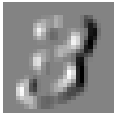

In [ ]:
show_image(out_unf.view(26,26));

Let's see how much more quickly the kernel can be applied after reshaping.

In [ ]:
%timeit tensor([[apply_kernel(i,j,left_edge) for j in rng] for i in rng])

4.79 ms ± 65.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
%timeit (inp_unf@w).view(26,26)

4.84 μs ± 19.4 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


_Multitudes_ quicker!

In [ ]:
F.unfold(im3[None,None,...], (3,3))[0].shape

torch.Size([9, 676])

In [ ]:
inp_unf = F.unfold(im3[None,None,...], (3,3))[0]

In [ ]:
%timeit (w@inp_unf).view(26,26)

5.36 μs ± 12.5 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


Interstingly, making the weights the second matrix slows down the process. 🤔

In [ ]:
?F.conv2d

Docstring:
conv2d(input, weight, bias=None, stride=1, padding=0, dilation=1, groups=1) -> Tensor

Applies a 2D convolution over an input image composed of several input
planes.

This operator supports :ref:`TensorFloat32<tf32_on_ampere>`.

See :class:`~torch.nn.Conv2d` for details and output shape.

Note:
    In some circumstances when given tensors on a CUDA device and using CuDNN, this operator may select a nondeterministic algorithm to increase performance. If this is undesirable, you can try to make the operation deterministic (potentially at a performance cost) by setting ``torch.backends.cudnn.deterministic = True``. See :doc:`/notes/randomness` for more information.

Note:
    This operator supports complex data types i.e. ``complex32, complex64, complex128``.


Args:
    input: input tensor of shape :math:`(\text{minibatch} , \text{in\_channels} , iH , iW)`
    weight: filters of shape :math:`(\text{out\_channels} , \frac{\text{in\_channels}}{\text{groups}} , kH , kW)`
    bias

In [ ]:
left_edge.shape, left_edge[None,None].shape

(torch.Size([3, 3]), torch.Size([1, 1, 3, 3]))

In [ ]:
%timeit F.conv2d(inp_unf[None,None], left_edge[None,None])

23 μs ± 271 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


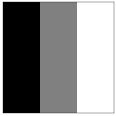

In [ ]:
show_image(left_edge, noframe=False);

In [ ]:
left_edge

tensor([[-1.,  0.,  1.],
        [-1.,  0.,  1.],
        [-1.,  0.,  1.]])

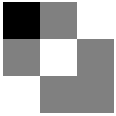

In [ ]:
diag1_edge = tensor([[-1, 0, 1],
                     [0, 1, 0],
                     [1, 0, 0]]).float()
show_image(diag1_edge);

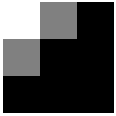

In [ ]:
diag1_edge = tensor([[1, 0, -1],
                     [0, -1, -1],
                     [-1, -1, -1]]).float()
show_image(diag1_edge);

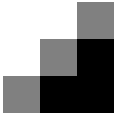

In [ ]:
diag1_edge = tensor([[1,  1,   0],
                     [1,  0,  -1],
                     [0, -1, -1]]).float()
show_image(diag1_edge);

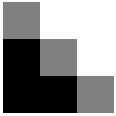

In [ ]:
diag2_edge = tensor([[ 0,  1,  1],
                     [-1,  0,  1],
                     [-1, -1,  0]]).float()
show_image(diag2_edge);

In [ ]:
inp_unf.shape

torch.Size([9, 676])

In [ ]:
diag1_edge.flatten().shape

torch.Size([9])

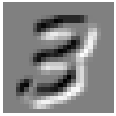

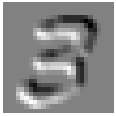

In [ ]:
show_image((diag1_edge.flatten()@inp_unf).view(26,26)), show_image((diag2_edge.flatten()@inp_unf).view(26,26));

In [ ]:
xb = ximgs[:16]; xb.shape

torch.Size([16, 28, 28])

In [ ]:
xb = xb[:,None]

In [ ]:
edge_kernels = torch.stack([left_edge,top_edge,diag1_edge,diag2_edge]); edge_kernels.shape

torch.Size([4, 3, 3])

In [ ]:
edge_kernels = edge_kernels[:, None, ...]; edge_kernels.shape

torch.Size([4, 1, 3, 3])

In [ ]:
batch_features = F.conv2d(xb, edge_kernels); batch_features.shape

torch.Size([16, 4, 26, 26])

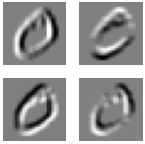

In [ ]:
show_images([batch_features[1,i] for i in range(4)])

## Creating the CNN

In [ ]:
n,m = xtrn.shape
c = ytrn.max()+1
nh = 50

In [ ]:
n,m,c,nh

(50000, 784, tensor(10), 50)

Let's first create a basic neural network.

In [ ]:
from torch import nn

In [ ]:
model = nn.Sequential(nn.Linear(m,nh), nn.ReLU(), nn.Linear(nh,10)) # 

However, we can't just create a CNN in the same way.

In [ ]:
?nn.Conv2d

Init signature:
nn.Conv2d(
    in_channels: int,
    out_channels: int,
    kernel_size: Union[int, Tuple[int, int]],
    stride: Union[int, Tuple[int, int]] = 1,
    padding: Union[str, int, Tuple[int, int]] = 0,
    dilation: Union[int, Tuple[int, int]] = 1,
    groups: int = 1,
    bias: bool = True,
    padding_mode: str = 'zeros',
    device=None,
    dtype=None,
) -> None
Docstring:     
Applies a 2D convolution over an input signal composed of several input
planes.

In the simplest case, the output value of the layer with input size
:math:`(N, C_{\text{in}}, H, W)` and output :math:`(N, C_{\text{out}}, H_{\text{out}}, W_{\text{out}})`
can be precisely described as:

.. math::
    \text{out}(N_i, C_{\text{out}_j}) = \text{bias}(C_{\text{out}_j}) +
    \sum_{k = 0}^{C_{\text{in}} - 1} \text{weight}(C_{\text{out}_j}, k) \star \text{input}(N_i, k)


where :math:`\star` is the valid 2D `cross-correlation`_ operator,
:math:`N` is a batch size, :math:`C` denotes a number of channels,
:

In [ ]:
broken_cnn = nn.Sequential(
  nn.Conv2d(1,30,kernel_size=3,padding=1),
  nn.ReLU(),
  nn.Conv2d(30,10,kernel_size=3,padding=1)
)

In [ ]:
broken_cnn(xb).shape

torch.Size([16, 10, 28, 28])

We end up with 10 probabilities for _every_ pixel in an image. To fix this, we need to introduce a larger stride so that the resulting maps from a convolution are smaller.

In [ ]:
#| export
def conv(ni, nf, ks=3, stride=2, act=True):
  res = nn.Conv2d(ni, nf, kernel_size=ks, stride=stride, padding=ks//2)
  if act: res = nn.Sequential(res, nn.ReLU())
  return res

In [ ]:
simple_cnn = nn.Sequential(
  conv( 1, 4), # 14x14 activation map
  conv( 4, 8), # 7x7 activation map
  conv( 8,16), # 4x4 activation map
  conv(16,16), # 2x2
  conv(16,10, act=False), # 1x1
  nn.Flatten()
)

With a 1x1 activation map, we now have only 10 probabilities for every image.

In [ ]:
simple_cnn(xb).shape

torch.Size([16, 10])

In [ ]:
ximgs.shape

torch.Size([50000, 28, 28])

In [ ]:
ximgs = xtrn.view(-1,1,28,28); ximgs.shape

torch.Size([50000, 1, 28, 28])

In [ ]:
xvimgs = xvld.view(-1,1,28,28)

In [ ]:
# from xiaoai.training import *
# trn_ds, vld_ds = Dataset

## Export -

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()